# LoRA Fine-Tuning Assignment

## Objective

Apply what you learned in the SFT + LoRA tutorial to fine-tune **TinyLlama-1.1B** on the **databricks-dolly-15k** dataset using LoRA.

## What is provided

- All installation, import, and utility cells are provided.
- Each task cell has a comment block describing exactly what you need to write.

## What you need to do

Fill in every cell marked with `# YOUR CODE HERE`. There are **8 tasks** in total.

## Prerequisites

- You have completed the SFT + LoRA tutorial notebook.
- Runtime: **GPU** (T4 is sufficient).

---
## Part 0 — Setup (provided)

In [2]:
import torch
import gc
import os
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, PeftModel, get_peft_model
from trl import SFTConfig, SFTTrainer

# Check for Apple Silicon GPU (MPS)
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("MPS (Apple Silicon GPU) is available!")
else:
    print("MPS not found. Falling back to CPU.")

print(f"PyTorch version: {torch.__version__}")

MPS (Apple Silicon GPU) is available!
PyTorch version: 2.8.0


/var/folders/mb/f100qzmd05x0l68g518l8k_w0000gn/T/ipykernel_16876/2246156563.py:7: FutureWarning: Support for Python 3.9 will be dropped in the next release (after its end-of-life on October 31, 2025). Please upgrade to Python 3.10 or newer.
  from trl import SFTConfig, SFTTrainer


### Utility functions (provided)

In [21]:
def clear_memory():
    """Free memory between experiments (Updated for Mac)."""
    gc.collect()
    if torch.backends.mps.is_available():
        # Clear the MPS cache
        torch.mps.empty_cache()
        # Note: Mac memory management is handled by the OS;
        # mps.empty_cache() tells the driver to release unused memory back to the system.
        print("MPS memory cache cleared.")
    elif torch.cuda.is_available():
        torch.cuda.empty_cache()
        print(f"GPU allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")


def print_trainable_params(model):
    """Display trainable vs total parameter counts."""
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Trainable parameters: {trainable:>12,}  ({100 * trainable / total:.4f}%)")
    print(f"Total parameters:     {total:>12,}")


def generate_response(model, tokenizer, prompt, max_new_tokens=256):
    """Generate a response from a model given a prompt string."""
    messages = [{"role": "user", "content": prompt}]
    input_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=None,
            top_p=0.9,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
        )
    response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return response

---
## Part 1 — Configuration

### Task 1: Define all hyperparameters

Set the following configuration variables:

| Variable | Value |
|---|---|
| `MODEL_NAME` | `"TinyLlama/TinyLlama-1.1B-Chat-v1.0"` |
| `DATASET_NAME` | `"databricks/databricks-dolly-15k"` |
| `NUM_TRAIN_SAMPLES` | `1000` |
| `MAX_SEQ_LENGTH` | `512` |
| `LORA_R` | `8` |
| `LORA_ALPHA` | `16` |
| `LORA_DROPOUT` | `0.05` |
| `LORA_TARGET_MODULES` | `["q_proj", "v_proj"]` (attention only) |
| `LEARNING_RATE` | `2e-4` |
| `NUM_EPOCHS` | `1` |
| `BATCH_SIZE` | `4` |
| `GRAD_ACCUM_STEPS` | `4` |
| `OUTPUT_DIR` | `"./sft-lora-tinyllama"` |

In [5]:
# --- Part 1: Configuration ---

# Model and Dataset
MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
DATASET_NAME = "databricks/databricks-dolly-15k"
NUM_TRAIN_SAMPLES = 1000
MAX_SEQ_LENGTH = 512

# LoRA Hyperparameters
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.05
LORA_TARGET_MODULES = ["q_proj", "v_proj"]

# Training Hyperparameters
LEARNING_RATE = 2e-4
NUM_EPOCHS = 1
BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 4
OUTPUT_DIR = "./sft-lora-tinyllama"

# Mac-Specific Settings (M5 Pro)
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
DTYPE = torch.bfloat16

print(f"Configuration set. Targeted Device: {DEVICE}")


Configuration set. Targeted Device: mps


---
## Part 2 — Load Model and Tokenizer

### Task 2: Load the tokenizer and base model

1. Load the tokenizer from `MODEL_NAME`.
2. If the tokenizer has no pad token, set it to the eos token.
3. Load the model in `float16` with `device_map="auto"`.
4. Print the total parameter count.

In [6]:
# --- Part 2: Load Model and Tokenizer ---

print(f"Loading tokenizer and model: {MODEL_NAME}...")

# 1. Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

# 2. Handle the padding token
# TinyLlama and many other LLMs don't have a default pad_token.
# We set it to eos_token so the model knows where to stop attending.
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

# 3. Load the model in float16
# device_map="auto" will automatically detect your M5 Pro's MPS device.
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=DTYPE,
    device_map=DEVICE,
    trust_remote_code=True
)

# 4. Print total parameter count
total_params = sum(p.numel() for p in model.parameters())
print(f"\nModel loaded successfully on device: {model.device}")
print(f"Total parameters: {total_params:,}")

# Let's use your utility function from earlier to see the baseline
print_trainable_params(model)


Loading tokenizer and model: TinyLlama/TinyLlama-1.1B-Chat-v1.0...

Model loaded successfully on device: mps:0
Total parameters: 1,100,048,384
Trainable parameters: 1,100,048,384  (100.0000%)
Total parameters:     1,100,048,384


---
## Part 3 — Test Base Model

### Task 3: Generate responses from the base model

Use the provided `generate_response` function with these test prompts:
1. `"Explain what a neural network is in 2-3 sentences."`
2. `"What are three tips for better sleep?"`

Store the responses in a list called `base_responses` for later comparison.

In [7]:
# --- Part 3: Test Base Model ---

test_prompts = [
    "Explain what a neural network is in 2-3 sentences.",
    "What are three tips for better sleep?"
]

base_responses = []

print("--- Generating Base Model Responses ---")

for i, prompt in enumerate(test_prompts):
    print(f"\nPrompt {i+1}: {prompt}")

    response = generate_response(model, tokenizer, prompt)

    base_responses.append(response)
    print(f"Response {i+1}:\n{response}")

print("\nBase responses stored for later comparison.")


--- Generating Base Model Responses ---

Prompt 1: Explain what a neural network is in 2-3 sentences.
Response 1:
A neural network is a mathematical model that mimics the functioning of the human brain. It consists of a series of interconnected units, called neurons, which are responsible for processing information and making decisions. Neurons can receive input from other neurons through synapses, which are connections formed between neurons through the action of chemical messengers called neurotransmitters. These synaptic connections allow neurons to communicate with each other and share information. The process of learning, or training, involves gradually exposing the neural network to new information and adjusting the synaptic connections to optimize its performance. Neural networks are used in a variety of applications, including image recognition, speech recognition, and machine learning.

Prompt 2: What are three tips for better sleep?
Response 2:
1. Create a consistent sleep sc

---
## Part 4 — Prepare the Dataset

### Task 4: Load and format the Dolly dataset

The Dolly dataset has columns: `instruction`, `context`, `response`, `category`.

1. Load the dataset (`split="train"`).
2. Write a function `format_dolly_to_chat(example)` that converts each example to:
   ```python
   {"messages": [
       {"role": "user", "content": <instruction + context if present>},
       {"role": "assistant", "content": <response>}
   ]}
   ```
   If `context` is non-empty, concatenate it to the instruction with a newline separator.
3. Shuffle with `seed=42`, select `NUM_TRAIN_SAMPLES` examples, and apply the formatting function.
4. Print the size of the formatted dataset and one example.



```
Example formatted entry:
{'messages': [{'content': 'Who were the children of the legendary Garth Greenhand, the High King of the First Men in the series A Song of Ice and Fire?', 'role': 'user'}, {'content': 'Garth the Gardener, John the Oak, Gilbert of the Vines, Brandon of the Bloody Blade, Foss the Archer, Owen Oakenshield, Harlon the Hunter, Herndon of the Horn, Bors the Breaker, Florys the Fox, Maris the Maid, Rose of the Red Lake, Ellyn Ever Sweet, Rowan Gold-Tree', 'role': 'assistant'}]}
```



In [8]:
# --- Part 4: Prepare the Dataset ---

print(f"Loading and formatting dataset: {DATASET_NAME}...")

# 1. Load the dataset (split='train')
full_dataset = load_dataset(DATASET_NAME, split="train")

# 2. Define the formatting function
def format_dolly_to_chat(example):
    """
    Converts Dolly format to standardized OpenAI-style messages.
    Concatenates instruction and context if context exists.
    """
    # Combine instruction and context
    user_content = example["instruction"]
    if example["context"] and example["context"].strip():
        user_content += "\n\n" + example["context"]

    # Create the structured message format
    formatted_entry = {
        "messages": [
            {"role": "user", "content": user_content},
            {"role": "assistant", "content": example["response"]}
        ]
    }
    return formatted_entry

# 3. Shuffle, Select, and Apply formatting
# We shuffle first to ensure we get a diverse mix of categories (Creative Writing, QA, etc.)
formatted_dataset = full_dataset.shuffle(seed=42).select(range(NUM_TRAIN_SAMPLES))
formatted_dataset = formatted_dataset.map(format_dolly_to_chat, remove_columns=full_dataset.column_names)

# 4. Print stats and a sample
print(f"Dataset processing complete.")
print(f"Total training samples: {len(formatted_dataset)}")
print("-" * 30)
print("Example formatted entry:")
import pprint
pprint.pprint(formatted_dataset[0])


Loading and formatting dataset: databricks/databricks-dolly-15k...
Dataset processing complete.
Total training samples: 1000
------------------------------
Example formatted entry:
{'messages': [{'content': 'Who were the children of the legendary Garth '
                          'Greenhand, the High King of the First Men in the '
                          'series A Song of Ice and Fire?',
               'role': 'user'},
              {'content': 'Garth the Gardener, John the Oak, Gilbert of the '
                          'Vines, Brandon of the Bloody Blade, Foss the '
                          'Archer, Owen Oakenshield, Harlon the Hunter, '
                          'Herndon of the Horn, Bors the Breaker, Florys the '
                          'Fox, Maris the Maid, Rose of the Red Lake, Ellyn '
                          'Ever Sweet, Rowan Gold-Tree',
               'role': 'assistant'}]}


---
## Part 5 — Configure LoRA

### Task 5: Create the LoRA config and inspect trainable parameters

1. Create a `LoraConfig` using the hyperparameters from Task 1. Set `bias="none"` and `task_type="CAUSAL_LM"`.
2. Apply it to the model with `get_peft_model`.
3. Use `print_trainable_params` to display the trainable vs total parameters.
4. Print the LoRA-wrapped structure of one attention layer (e.g., `q_proj` of layer 0).

In [9]:
# --- Part 5: Configure LoRA ---

# 1. Create the LoRA configuration
# We use the hyperparameters defined in Task 1
peft_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET_MODULES,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM"
)

# 2. Wrap the base model with the LoRA configuration
# This "freezes" the base model and adds the adapter layers
model = get_peft_model(model, peft_config)

# 3. Inspect trainable parameters using your utility function
print("--- PEFT Trainable Parameter Summary ---")
print_trainable_params(model)

# 4. Inspect the internal structure of an attention layer
# This shows exactly how the 'lora_A' and 'lora_B' matrices were injected
print("\n--- Structural Inspection (Layer 0: q_proj) ---")
print(model.model.model.layers[0].self_attn.q_proj)



--- PEFT Trainable Parameter Summary ---
Trainable parameters:    1,126,400  (0.1023%)
Total parameters:     1,101,174,784

--- Structural Inspection (Layer 0: q_proj) ---
lora.Linear(
  (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
  (lora_dropout): ModuleDict(
    (default): Dropout(p=0.05, inplace=False)
  )
  (lora_A): ModuleDict(
    (default): Linear(in_features=2048, out_features=8, bias=False)
  )
  (lora_B): ModuleDict(
    (default): Linear(in_features=8, out_features=2048, bias=False)
  )
  (lora_embedding_A): ParameterDict()
  (lora_embedding_B): ParameterDict()
  (lora_magnitude_vector): ModuleDict()
)


---
## Part 6 — Train

### Task 6: Set up SFTTrainer and run training

1. Delete the PEFT-wrapped model and call `clear_memory()`. Reload the base model fresh (SFTTrainer applies LoRA itself via `peft_config`).
2. Create an `SFTConfig` with the hyperparameters from Task 1. Include:
   - Cosine LR scheduler, warmup ratio 0.03, weight decay 0.01
   - `gradient_checkpointing=True`
   - bf16 if supported, else fp16
   - `max_length=MAX_SEQ_LENGTH`
   - Logging every 10 steps
3. Create an `SFTTrainer` with the model, training args, dataset, tokenizer, and `peft_config`.
4. Call `trainer.train()` and print the final loss.

In [10]:
# --- Part 6: Train  ---

# 1. Clear memory
if 'model' in locals():
    del model
clear_memory()

# 2. Reload base model
# We keep torch_dtype=torch.float16 here for the model weights
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

# 3. Define SFTConfig
sft_config = SFTConfig(
    output_dir=OUTPUT_DIR,
    max_length=MAX_SEQ_LENGTH,
    dataset_text_field="messages",

    # Hyperparameters
    learning_rate=LEARNING_RATE,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,

    # Optimization & Mac Efficiency
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    weight_decay=0.01,
    gradient_checkpointing=True,

    # --- MAC SPECIFIC FIX ---
    # We set fp16=False because 'accelerate' dislikes it on MPS.
    # We use bf16=True if you want mixed precision,
    # OR leave both False to use the model's native float16.
    fp16=False,
    bf16=True, # M5 Pro supports BFloat16 natively and it's better for LLMs
    # ------------------------

    # Logging
    logging_steps=10,
    save_strategy="no",
    report_to="none"
)

# 4. Initialize the SFTTrainer
trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=formatted_dataset,
    peft_config=peft_config,
    processing_class=tokenizer
)

# 5. Run Training
print("\n" + "="*30)
print("STARTING TRAINING ON M5 PRO (MPS)...")
print("="*30)

train_result = trainer.train()

print(f"\nTraining complete! Final Loss: {train_result.training_loss:.4f}")

MPS memory cache cleared.


`torch_dtype` is deprecated! Use `dtype` instead!
The model is already on multiple devices. Skipping the move to device specified in `args`.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.
/Users/kishankunal/workspace/AppliedAI/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)



STARTING TRAINING ON M5 PRO (MPS)...


Step,Training Loss
10,1.901800
20,1.797900
30,1.715000
40,1.699100
50,1.739000
60,1.755000



Training complete! Final Loss: 1.7679


---
## Part 7 — Save the Adapter

### Task 7: Save the LoRA adapter and print its size

1. Save the trained model to `f"{OUTPUT_DIR}/final-adapter"`.
2. Also save the tokenizer to the same path.
3. Compute and print the adapter size in MB.

In [11]:
import os

# 1. Define the save path
ADAPTER_PATH = f"{OUTPUT_DIR}/final-adapter"

# 2. Save the trained LoRA adapter and the tokenizer
# Note: This only saves the 'delta' weights (the A and B matrices)
print(f"Saving adapter and tokenizer to {ADAPTER_PATH}...")
trainer.model.save_pretrained(ADAPTER_PATH)
tokenizer.save_pretrained(ADAPTER_PATH)

# 3. Compute and print the adapter size in MB
def get_dir_size(path):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            # skip if it is symbolic link
            if not os.path.islink(fp):
                total_size += os.path.getsize(fp)
    return total_size / (1024 * 1024)

adapter_size_mb = get_dir_size(ADAPTER_PATH)
print(f"\n" + "="*30)
print(f"ADAPTER SAVED SUCCESSFULLY")
print(f"Total Adapter Size: {adapter_size_mb:.2f} MB")
print("="*30)


Saving adapter and tokenizer to ./sft-lora-tinyllama/final-adapter...

ADAPTER SAVED SUCCESSFULLY
Total Adapter Size: 7.77 MB


---
## Part 8 — Evaluate

### Task 8: Compare base vs fine-tuned responses

1. Use `trainer.model` (already has LoRA weights) to generate responses for the same `test_prompts`.
2. Print a side-by-side comparison of base vs fine-tuned responses.

In [12]:
# --- Part 8: Evaluate & Compare ---

print("--- Generating Fine-Tuned Model Responses ---")
ft_responses = []

# Set model to evaluation mode (disables dropout for consistent results)
trainer.model.eval()

# We use the same test_prompts defined in Part 3
for i, prompt in enumerate(test_prompts):
    print(f"Generating for Prompt {i+1}: {prompt}...")

    # Use your validated generate_response function
    # On the M5 Pro, this uses the MPS device through the trainer.model
    response = generate_response(trainer.model, tokenizer, prompt)

    ft_responses.append(response)

# --- Final Side-by-Side Comparison ---
print("\n" + "="*80)
print("FINAL COMPARISON: BASE VS. FINE-TUNED (Dolly-15k)")
print("="*80)

for i in range(len(test_prompts)):
    print(f"\nPROMPT: {test_prompts[i]}")
    print("-" * 40)
    print(f"BEFORE (Base TinyLlama):\n{base_responses[i]}")
    print("-" * 20)
    print(f"AFTER (Your LoRA Fine-Tune):\n{ft_responses[i]}")
    print("="*80)


--- Generating Fine-Tuned Model Responses ---
Generating for Prompt 1: Explain what a neural network is in 2-3 sentences....
Generating for Prompt 2: What are three tips for better sleep?...

FINAL COMPARISON: BASE VS. FINE-TUNED (Dolly-15k)

PROMPT: Explain what a neural network is in 2-3 sentences.
----------------------------------------
BEFORE (Base TinyLlama):
A neural network is a mathematical model that mimics the functioning of the human brain. It consists of a series of interconnected units, called neurons, which are responsible for processing information and making decisions. Neurons can receive input from other neurons through synapses, which are connections formed between neurons through the action of chemical messengers called neurotransmitters. These synaptic connections allow neurons to communicate with each other and share information. The process of learning, or training, involves gradually exposing the neural network to new information and adjusting the synaptic conne

---
## using LLM as a Judge

## Setup and Judge Initialization

In [18]:
import os
from dotenv import load_dotenv
from opik.evaluation.metrics import AnswerRelevance, Hallucination, Moderation
import opik
from opik import Opik

# 1. Load Keys
load_dotenv(override=True)

# Set Opik Environment (Bypasses the ConfigurationError)
os.environ["OPIK_API_KEY"] = os.getenv("OPIK_API_KEY")
os.environ["OPIK_WORKSPACE"] = os.getenv("OPIK_WORKSPACE")
os.environ["OPIK_PROJECT_NAME"] = "TinyLlama-Dolly-Evaluation"

# Set GitHub Models as the Judge Backend (OpenAI-compatible)
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["OPENAI_BASE_URL"] = "https://models.inference.ai.azure.com"

# 2. Initialize the Judge Metrics
# We use GPT-4o from GitHub to judge our local TinyLlama
judge_model = "openai/gpt-4o-mini"

opik.configure(
    api_key=os.getenv("OPIK_API_KEY"),
    workspace=os.getenv("OPIK_WORKSPACE"),
    force=True,
    use_local=False
)
client = opik.Opik()

scoring_metrics = [
    AnswerRelevance(model=judge_model),
    Hallucination(model=judge_model),
    Moderation(model=judge_model) # Checks for safety/harmful content
]
print("✅ Prerequisites met. Judge is ready.")

OPIK: Existing Opik clients will not use updated values for "url", "api_key", "workspace".
OPIK: Configuration saved to file: /Users/kishankunal/.opik.config
OPIK: Configuration completed successfully. Traces will be logged to 'TinyLlama-Dolly-Evaluation' project. To change the destination project, see: https://www.comet.com/docs/opik/tracing/log_traces#configuring-the-project-name


✅ Prerequisites met. Judge is ready.


## Uploading the Dataset to Opik

In [19]:
#Create a managed Dataset in the Opik Cloud/Local platform
DATASET_NAME = "Dolly-TinyLlama-Eval-Set"
opik_dataset = client.get_or_create_dataset(
    name=DATASET_NAME,
    description="A subset of Dolly-15k for judging TinyLlama fine-tuning"
)

# 3. Prepare the records for upload
# We map your HF 'messages' to Opik's 'input' and 'expected_output' fields
# We'll take a small slice (e.g., 20 samples) for evaluation to save on Judge API costs
eval_samples = formatted_dataset.select(range(20))

records = []
for item in eval_samples:
    records.append({
        "input": item["messages"][0]["content"],       # The Instruction
        "expected_output": item["messages"][1]["content"] # The Ground Truth
    })

# 4. Insert into Opik
# Opik handles deduplication automatically!
opik_dataset.insert(records)

print(f"✅ Dataset '{DATASET_NAME}' is ready with {len(records)} items.")
print(f"🔗 View it at: https://www.comet.com/{os.getenv('OPIK_WORKSPACE')}/opik/datasets")

✅ Dataset 'Dolly-TinyLlama-Eval-Set' is ready with 20 items.
🔗 View it at: https://www.comet.com/kishan-kunal/opik/datasets


## Run Evaluation

In [ ]:
%pip install ipywidgets

In [23]:
import opik.api_objects.opik_client as opik_client
from opik.evaluation import evaluate

# 1. Reset cache
opik_client.get_client_cached.cache_clear()

# 2. Task ONLY generates text (NO scoring_metrics passed here)
def inference_only_task(dataset_item):
    user_query = dataset_item["input"]
    response = generate_response(trainer.model, tokenizer, user_query)
    return {
        "output": response,
        "input": user_query,
        "context": [user_query]
    }

print("🚀 Running Local Inference on M5 Pro...")
# We run this WITHOUT metrics to avoid calling GitHub GPT-4o
res = evaluate(
    dataset=opik_dataset,
    task=inference_only_task,
    project_name="TinyLlama-Dolly-Evaluation",
    experiment_name="TinyLlama-Dolly-v1-Inference",
    nb_samples=20,
    task_threads=1 # Still best for local thermal management
)
print("✅ Inference complete. Responses saved to Opik.")

🚀 Running Local Inference on M5 Pro...


Evaluation:   0%|          | 0/20 [00:00<?, ?it/s]

OPIK: Started logging traces to the "TinyLlama-Dolly-Evaluation" project at https://www.comet.com/opik/api/v1/session/redirect/projects/?trace_id=019d3ac7-8ff8-7663-b6f9-7c215b74faa7&path=aHR0cHM6Ly93d3cuY29tZXQuY29tL29waWsvYXBpLw==.


╭─ Dolly-TinyLlama-Eval-Set (20 samples) ─╮
│                                         │
│ Total time:        00:00:20             │
│ Number of samples: 20                   │
│                                         │
│                                         │
╰─────────────────────────────────────────╯

Uploading results to Opik ...

View the results ]8;id=45561;https://www.comet.com/opik/api/v1/session/redirect/experiments/?experiment_id=019d3ac7-7d22-740f-9efe-8430549f5418&dataset_id=019d3a97-6e63-77fd-ae5d-dfb66ec58f16&path=aHR0cHM6Ly93d3cuY29tZXQuY29tL29waWsvYXBpLw==\in your Opik dashboard]8;;\.

✅ Inference complete. Responses saved to Opik.


In [26]:
# 1. Initialize Metrics with 'require_context=False' if you don't have retrieval context
from opik.evaluation.metrics import AnswerRelevance, Hallucination
import pandas as pd
import time

results_df = pd.DataFrame(res.test_results)

# Initialize metrics - setting require_context=False allows scoring
# based just on the Prompt vs Response if needed.
metrics = [
    AnswerRelevance(model=judge_model, require_context=False),
    Hallucination(model=judge_model)
]

print("⚖️ Flattening data and calling GitHub Judge...")

def get_scores(row):
    time.sleep(1)
    scores = {}

    # --- EXTRACT FROM NESTED 'test_case' ---
    test_case = row.get('test_case', {})

    # Mapping the nested fields to what the metrics expect
    input_text = test_case.get('input')
    output_text = row.get('output') # Usually in the root or 'output'

    # If context is missing, we pass the input as context or an empty list
    # Hallucination metric MUST have a context list to check against
    context_list = test_case.get('context', [input_text])

    try:
        for metric in metrics:
            score_result = metric.score(
                input=input_text,
                output=output_text,
                context=context_list
            )
            scores[metric.name] = score_result.value
    except Exception as e:
        print(f"⚠️ Row scoring failed: {e}")
        scores['answer_relevance'] = 0
        scores['hallucination'] = 0

    return pd.Series(scores)

# Apply scoring
scored_data = results_df.apply(get_scores, axis=1)

# Combine original data with the new scores
# We also flatten the 'test_case' for easier plotting in Part 3
results_df['input'] = results_df['test_case'].apply(lambda x: x.get('input'))
results_df = pd.concat([results_df, scored_data], axis=1)

print("✅ Judging Complete.")

⚖️ Flattening data and calling GitHub Judge...
✅ Judging Complete.


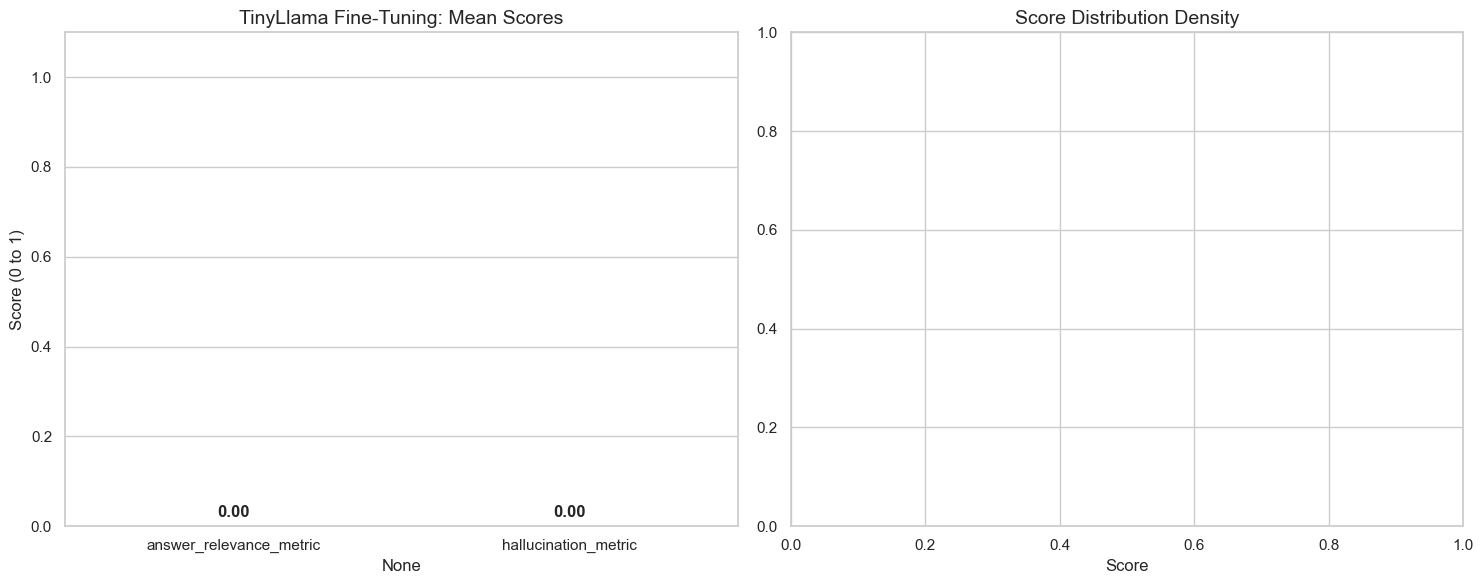

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. CLEAN & FLATTEN THE DATA
# Extract 'input' from the nested test_case dictionary if it's not at the top level
if 'input' not in results_df.columns or results_df['input'].isnull().all():
    results_df['input'] = results_df['test_case'].apply(lambda x: x.get('input') if isinstance(x, dict) else "N/A")

# Auto-detect metric columns (they were 'answer_relevance_metric' and 'hallucination_metric')
rel_col = next((c for c in results_df.columns if 'relevance' in c.lower()), None)
hal_col = next((c for c in results_df.columns if 'hallucination' in c.lower()), None)
metric_cols = [rel_col, hal_col]

# 2. SETUP VISUALS
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(15, 6))

# --- Graph 1: Average Scores (Bar Chart) ---
plt.subplot(1, 2, 1)
avg_scores = results_df[metric_cols].mean()

sns.barplot(
    x=avg_scores.index,
    y=avg_scores.values,
    hue=avg_scores.index,
    palette="viridis",
    legend=False
)

plt.title("TinyLlama Fine-Tuning: Mean Scores", fontsize=14)
plt.ylabel("Score (0 to 1)")
plt.ylim(0, 1.1) # Extra room for text labels

for i, v in enumerate(avg_scores.values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

# --- Graph 2: Score Distribution (Density) ---
plt.subplot(1, 2, 2)
colors = ["#4285F4", "#EA4335"]
has_plot = False

for col, color in zip(metric_cols, colors):
    # Only plot if we have more than one unique value (KDE requirement)
    if results_df[col].nunique() > 1:
        sns.kdeplot(data=results_df[col], fill=True, label=col.replace('_metric', '').title(), color=color)
        has_plot = True

plt.title("Score Distribution Density", fontsize=14)
plt.xlabel("Score")

if has_plot:
    plt.legend()

plt.tight_layout()
plt.show()